Authors: Federico Gritti,  Alessandro Mecchia, Paolo Nicolet.

# Hotel revenue Forecasting Pipeline 

This notebook demonstrates the complete pipeline for forecasting hotel revenue values using various time series models, targeting multiple forecast horizons

# Forecasting pipeline

1.  **Exploratory analysis**:
    1.  Univariate statistical analysis (applied to averages or specific examples)
    2.  Descriptive statistics for multivariate TS
    3.  Correlation between TS
    4.  etc..
2.  **Univariate benchmark models**. Chose one or more benchmark methods we have seen in the course and retrieve a baseline in terms of performance
    1.  naive methods
    2.  Holt-Winters, AR(I)MAX
3.  **Model proposal and training**
    1.  cross validation (time or purged k-fold) and hyperpar optimization (potentially per target or averaged)
    2.  point and *probabilistic* forecasts
    3.  choice of the score metrics
4.  **Model selection**
    1.  Selection (potentially per target or overall best)
    2.  Reporting results



**Key Points:**
- Dataset covers 7 years of hotel demand and revenue data
- Contains daily occupancy, demand, and revenue for upper-middle class hotels
- We will focus on data from 2013-2020 (excluding post-2020 data due to COVID impact)
- Goal: Build 1-7 day ahead forecast for Revenue column using historical Demand, Occupancy as exogenous variables

**Locations:** Los Angeles, Orlando, New York, Las Vegas, Los Angeles, Washington, Dallas, Boston

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
from datetime import datetime, timedelta


## 1. Data Loading and Initial Exploration

In [2]:
# Load dataset
with open("hotels.pk", "rb") as f:
    df = pickle.load(f)

df.head()


/tmp/ipykernel_92543/608466254.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pickle.load(f)


,Location,Revenue,Demand,Occupancy
Date,,,,
2013-01-01,NewYork,2.442363e+06,13063.675000,81.991307
2013-01-02,NewYork,2.018559e+06,13069.608539,82.028548
2013-01-03,NewYork,1.927676e+06,13069.608539,82.028548
2013-01-04,NewYork,1.781664e+06,12653.271887,79.415502
2013-01-05,NewYork,1.824994e+06,12827.322364,80.507892


---
### Filtering for Boston location and date range 2013-2020 in the cell below.

In [3]:

print(df['Location'].unique())

# Filter for one city
CITY = "Boston"
df_boston = df[df['Location'] == CITY].copy()

# Use index (already DateTimeIndex)
df_boston.index = pd.to_datetime(df_boston.index)

# Restrict date range
df_boston = df_boston.loc[:"2020-01-01"]
df_boston.head()



['NewYork' 'Orlando' 'Chicago' 'LosAngeles' 'Washington' 'Atlanta'
 'Dallas' 'Boston']


,Location,Revenue,Demand,Occupancy
Date,,,,
2013-01-01,Boston,166542.843005,1896.791481,22.856617
2013-01-02,Boston,245252.313124,2744.958462,33.077154
2013-01-03,Boston,289687.425946,3172.063926,38.223838
2013-01-04,Boston,297390.047491,3308.052694,39.862523
2013-01-05,Boston,291848.455941,3235.525351,38.988557


In [4]:
print(df_boston.index.min(), "→", df_boston.index.max())

2013-01-01 00:00:00 → 2020-01-01 00:00:00



The dataset for Boston has been filtered and restricted to end on January 1, 2020, as intended, covering the period from the minimum date to 2020-01-01 without post-COVID data.


---

## Autocorrelation Analysis

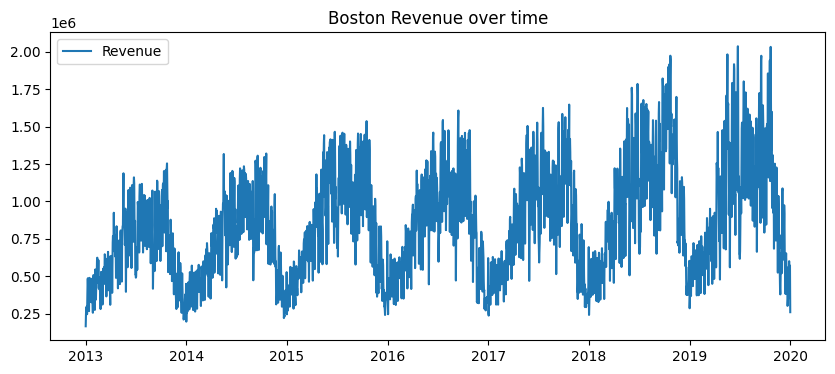

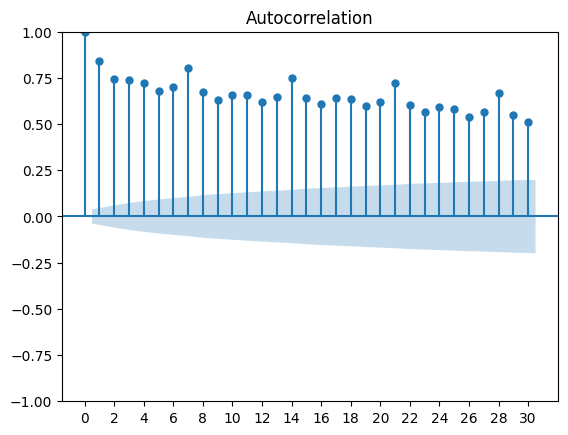

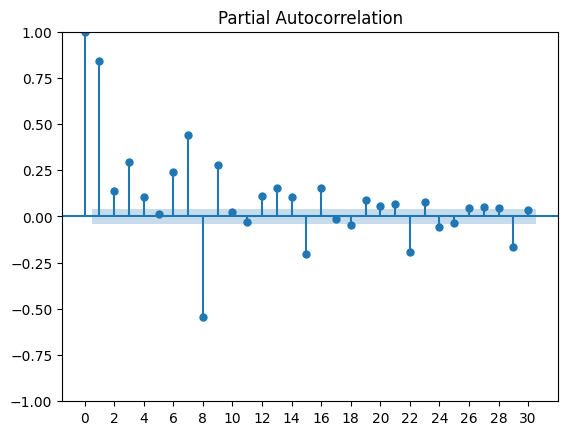

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller



# Plot revenue over time
plt.figure(figsize=(10,4))
plt.plot(df_boston['Revenue'], label="Revenue")
plt.title(f"{CITY} Revenue over time")
plt.legend()
plt.show()

plot_acf(df_boston['Revenue'].dropna(), lags=30)
plt.xticks(ticks=np.arange(0, 31, 2))
plt.show()
plot_pacf(df_boston['Revenue'].dropna(), lags=30)
plt.xticks(ticks=np.arange(0, 31, 2))
plt.show()





- The ACF plot shows clear peaks of autocorrelation every 7 days, indicating strong weekly seasonality in the Revenue data.
- The PACF plot reveals:
  - A moderate positive partial autocorrelation at lag 7 (approximately 0.5).
  - A significant negative partial autocorrelation at lag 8 (approximately -0.5).

These patterns suggest that the time series exhibits weekly cycles, with potential influences from the previous week's values and a negative adjustment at lag 8.

---

### Average Revenue by Weekday

/tmp/ipykernel_92543/1894399033.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dw = df_boston.groupby('weekday')['Revenue'].mean()


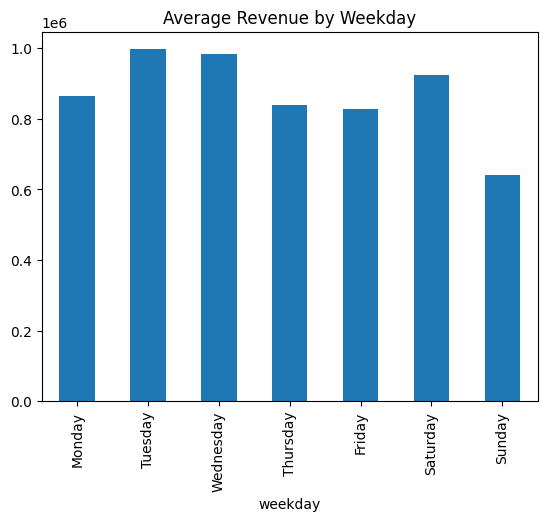

In [6]:
df_boston['weekday'] = df_boston.index.day_name()
df_boston['weekday'] = pd.Categorical(df_boston['weekday'], 
                                      categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
                                      ordered=True)
dw = df_boston.groupby('weekday')['Revenue'].mean()
# print("Mean revenue by weekday:")
# print(dw)
plt.figure()
dw.plot(kind='bar')
plt.title("Average Revenue by Weekday")
plt.show()


The average revenue by weekday shows a sinusoidal pattern, with revenues peaking on certain days and dipping on others, reflecting weekly cyclical behavior in hotel demand.

---

# Stationarity Test (ADF)


In [7]:
def test_adf(series, title=""):
    result = adfuller(series.dropna())
    print(f"ADF test for {title}:")
    print("  Test statistic:", result[0])
    print("  p-value:", result[1])
    print("  # lags used:", result[2])
    print("  # observations:", result[3])
    for key, val in result[4].items():
        print(f"    critical {key}:", val)
    print()
    
test_adf(df_boston['Revenue'], title="Revenue")


ADF test for Revenue:
  Test statistic: -3.068400879340803
  p-value: 0.028981774418438168
  # lags used: 27
  # observations: 2529
    critical 1%: -3.432938355012086
    critical 5%: -2.8626835272597217
    critical 10%: -2.567378742868999



The Augmented Dickey-Fuller test on the Revenue series indicates stationarity, with a p-value of approximately 0.029 (< 0.05), suggesting the series does not have a unit root and does not require differencing or transformation for stationarity.

# Forecastability Indicators
The forecastability indicators are needed to better understand the time series characteristics and to select appropriate forecasting models.

In [8]:
import antropy as ant
from typing import Dict, Union, Optional
from scipy import signal
from statsmodels.tsa.stattools import acf
import nolds
import ordpy

def variance_ratio(x: np.ndarray) -> Optional[float]:
    x = np.asarray(x, float)
    if x.size < 3:
        return np.nan
    num = np.nanvar(np.diff(x))
    den = np.nanvar(x)
    return float(num / den) if den > 0 else np.nan

def spectral_measures(x: np.ndarray) -> Dict[str, float]:
    x = np.asarray(x, float)
    if x.size < 16:
        return dict(spectral_entropy=np.nan, spectral_forecastability=np.nan, periodicity_index=np.nan)
    try:
        Hs = ant.spectral_entropy(x, sf=1.0, method='welch', normalize=True)
    except Exception:
        Hs = np.nan
    Omega = np.nan if np.isnan(Hs) else 1.0 - Hs
    try:
        freqs, psd = signal.periodogram(x, detrend='linear', scaling='density')
        if psd.size > 1:
            peak = np.nanmax(psd[1:])
            total = np.nansum(psd[1:])
            per_idx = (peak / total) if total and total > 0 else np.nan
        else:
            per_idx = np.nan
    except Exception:
        per_idx = np.nan
    return dict(spectral_entropy=Hs, spectral_forecastability=Omega, periodicity_index=per_idx)

def svd_entropy_safe(x: np.ndarray, order: int = 3, delay: int = 1) -> float:
    if x.size < order * delay + 1:
        return np.nan
    try:
        return ant.svd_entropy(x, order=order, delay=delay, normalize=True)
    except Exception:
        return np.nan

def perm_entropy_safe(x: np.ndarray, order: int = 5, delay: int = 1) -> float:
    if x.size < order * delay + 1:
        return np.nan
    try:
        return ant.perm_entropy(x, order=order, delay=delay, normalize=True)
    except Exception:
        return np.nan

def sample_entropy_safe(x: np.ndarray, m: int = 2, r_fraction: float = 0.2) -> float:
    x = np.asarray(x, float)
    if x.size < 20:
        return np.nan
    s = np.nanstd(x)
    if s == 0:
        return np.nan
    for rf in (r_fraction, 0.25, 0.15, 0.3):
        try:
            val = ant.sample_entropy(x, order=m)
            if np.isfinite(val):
                return float(val)
        except Exception as e:
            pass
    return np.nan

def approximate_entropy_safe(x: np.ndarray, m: int = 2, r_fraction: float = 0.2) -> float:
    x = np.asarray(x, float)
    if x.size < 20:
        return np.nan
    s = np.nanstd(x)
    if s == 0:
        return np.nan
    for rf in (r_fraction, 0.25, 0.15, 0.3):
        try:
            val = ant.app_entropy(x, order=m)
            if np.isfinite(val):
                return float(val)
        except Exception:
            pass
    return np.nan

def quantize_series(x: np.ndarray, n_bins: int = 8) -> np.ndarray:
    x = np.asarray(x, float)
    if np.unique(x).size <= 1:
        return np.zeros_like(x, dtype=int)
    try:
        q = pd.qcut(x, q=min(n_bins, max(2, np.unique(x).size)), labels=False, duplicates='drop')
        return q.astype(int).to_numpy()
    except Exception:
        bins = np.linspace(np.nanmin(x), np.nanmax(x), n_bins + 1)
        return np.digitize(x, bins[:-1], right=False).astype(int)

def lzc_safe(x: np.ndarray, n_bins: int = 8) -> float:
    if x.size < 16:
        return np.nan
    try:
        sym = quantize_series(x, n_bins=n_bins)
        return ant.lziv_complexity(sym, normalize=True)
    except Exception:
        return np.nan

def ordpy_complexity_entropy(x: np.ndarray, dx: int = 5, tau: int = 1) -> Dict[str, float]:
    x = np.asarray(x, float)
    if x.size < dx * tau + 1:
        return dict(ordpy_perm_entropy=np.nan, ordpy_stat_complexity=np.nan)
    try:
        # Newer ordpy API
        H, C = ordpy.complexity_entropy(x, dx=dx, dy=1, taux=tau, tauy=1, probs=False)
    except Exception as e:
        print(f"ordpy error: {e}")
        # Older ordpy API fallback
        H, C = ordpy.complexity_entropy(x, dx=dx, taux=tau)
    return dict(ordpy_perm_entropy=float(H), ordpy_stat_complexity=float(C))

def acf_measures(x: np.ndarray, max_lag: int = 52) -> Dict[str, float]:
    if x.size < max_lag + 2:
        return dict(acf1=np.nan, acf_mean_abs=np.nan)
    try:
        a = acf(x, nlags=max_lag, fft=True, missing='drop')
        a1 = float(a[1]) if a.size > 1 else np.nan
        asum = float(np.nanmean(np.abs(a[1:])))
        return dict(acf1=a1, acf_mean_abs=asum)
    except Exception:
        return dict(acf1=np.nan, acf_mean_abs=np.nan)

def dfa_alpha_safe(x: np.ndarray) -> float:
    if x.size < 64:
        return np.nan
    try:
        return float(nolds.dfa(x))
    except Exception:
        return np.nan

def ordinal_entropy(x: np.ndarray) -> Dict[str, float]:
    return ordpy_complexity_entropy(x, dx=5, tau=1)

#TypeError: 'float' object is not iterable 
# check the timeseries forecastability indicators
features = {}
series = df_boston['Revenue'].values



In [11]:
# Compute various forecastability indicators
features = {}
series = df_boston['Revenue'].values

features['variance_ratio'] = variance_ratio(series)
features['dfa_alpha'] = dfa_alpha_safe(series)
features.update(spectral_measures(series))
features.update(ordinal_entropy(series))
features.update(acf_measures(series))

print("Forecastability indicators:")
for key, value in features.items():
    print(f"{key}: {round(value, 4)}")

Forecastability indicators:
variance_ratio: 0.3202
dfa_alpha: 1.0979
spectral_entropy: 0.5821
spectral_forecastability: 0.4179
periodicity_index: 0.5308
ordpy_perm_entropy: 0.8706
ordpy_stat_complexity: 0.2013
acf1: 0.8387
acf_mean_abs: 0.5666


## Forecastability Indicators Analysis

The following table summarizes the computed forecastability indicators for the Boston Revenue time series, along with their values and interpretations:

| Indicator              | Value   | Interpretation |
|------------------------|---------|----------------|
| **variance_ratio**     | 0.3202 | Low value indicates trend presence (0 to 1 scale) |
| **dfa_alpha**          | 1.0979 | High value indicates long-range dependence (0 to ∞ scale) |
| **spectral_entropy**   | 0.5821 | Moderate value indicates some predictability (0 to 1 scale) |
| **spectral_forecastability** | 0.4179 | Low value indicates limited forecastability (0 to 1 scale) |
| **periodicity_index**  | 0.5308 | Moderate value indicates some periodicity (0 to 1 scale) |
| **ordpy_perm_entropy** | 0.8706 | High value indicates complex dynamics (0 to 1 scale) |
| **ordpy_stat_complexity** | 0.2013 | Low value indicates simple dynamics (0 to 1 scale) |
| **acf1**               | 0.8387 | High value indicates strong autocorrelation (0 to 1 scale) |
| **acf_mean_abs**       | 0.5666 | Moderate value indicates some autocorrelation (0 to 1 scale) |

**Overall Summary:**  
Looking at the forecastability indicators, the Revenue time series exhibits characteristics such as trend presence, long-range dependence, and strong autocorrelation. However, it also shows limited forecastability and complex dynamics, suggesting that while there are patterns to exploit, the series may be challenging to predict accurately.

# 2. Data Preprocessing

Before building models, we need to preprocess the data. This typically involves:
1.  **Handling Missing Values**: Identifying and imputing or removing missing data points.
2.  **Handling Outliers**: Identifying and potentially adjusting extreme values that could skew model training.
3.  **Feature Scaling**: Scaling numerical features to a common range (important for some models like neural networks).
4.  **Resampling**: Changing the frequency of the time series if needed (e.g., from daily to weekly). Our data is already daily, which matches the target frequency.



---
## Handling Missing Values

In [10]:
import plotly.express as px

missing_features_perc = (df_boston.isnull().sum() / len(df_boston)) * 100
missing_targets_perc = (df_boston.isnull().sum() / len(df_boston)) * 100
print("Missing feature percentages:\n", missing_features_perc)
print("Missing target percentages:\n", missing_targets_perc)


Missing feature percentages:
 Location     0.0
Revenue      0.0
Demand       0.0
Occupancy    0.0
weekday      0.0
dtype: float64
Missing target percentages:
 Location     0.0
Revenue      0.0
Demand       0.0
Occupancy    0.0
weekday      0.0
dtype: float64


We have no missing values in the dataset for both features and targets.

---

# Handling Outliers


/tmp/ipykernel_92543/699514431.py:29: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax[1].plot(df.index[is_outlier], df.iloc[is_outlier].values, 'r.', markersize=10, label='Outliers')


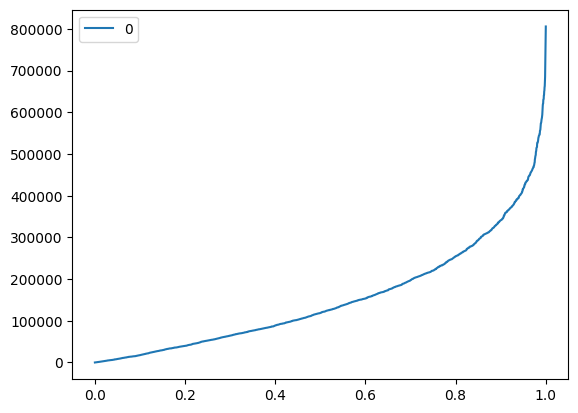

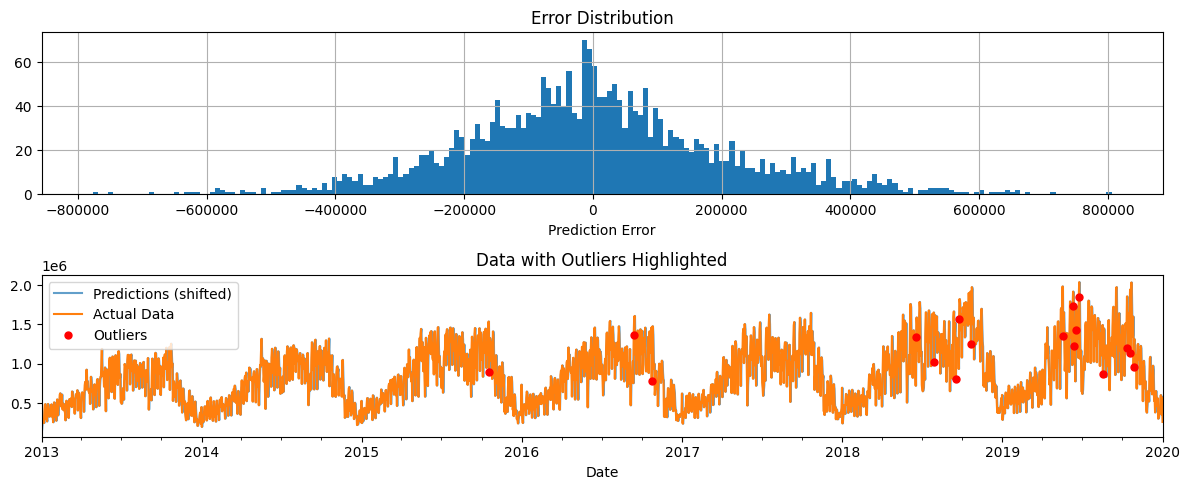

/tmp/ipykernel_92543/699514431.py:29: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax[1].plot(df.index[is_outlier], df.iloc[is_outlier].values, 'r.', markersize=10, label='Outliers')


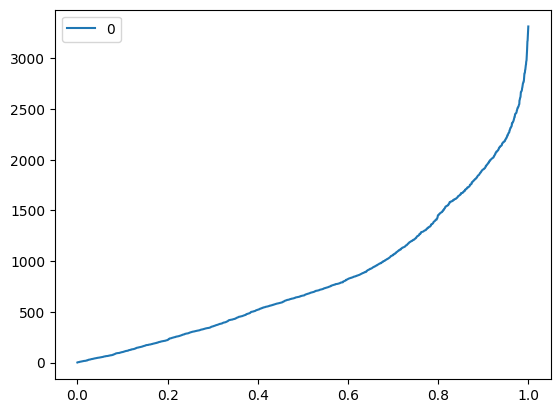

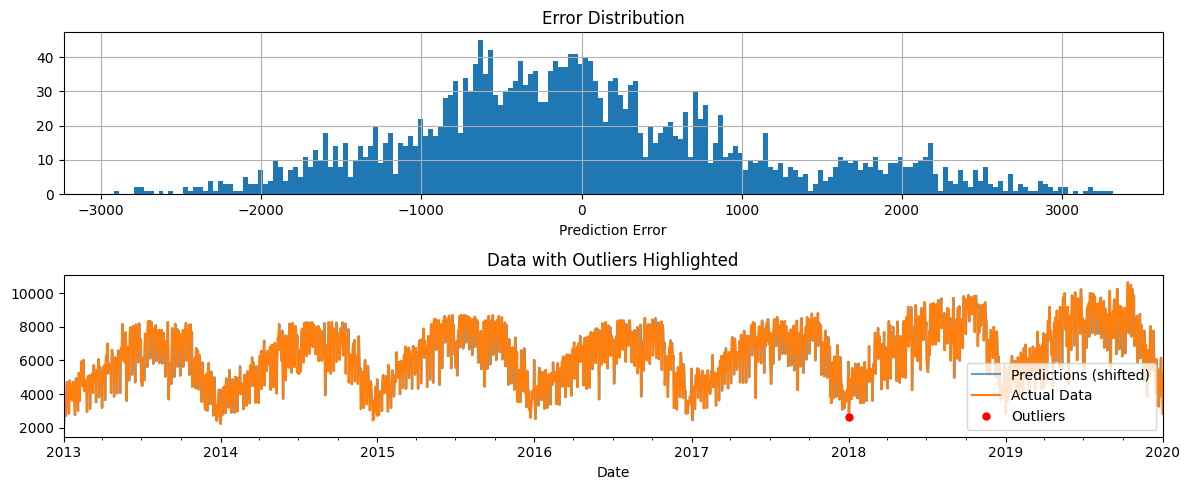

/tmp/ipykernel_92543/699514431.py:29: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax[1].plot(df.index[is_outlier], df.iloc[is_outlier].values, 'r.', markersize=10, label='Outliers')


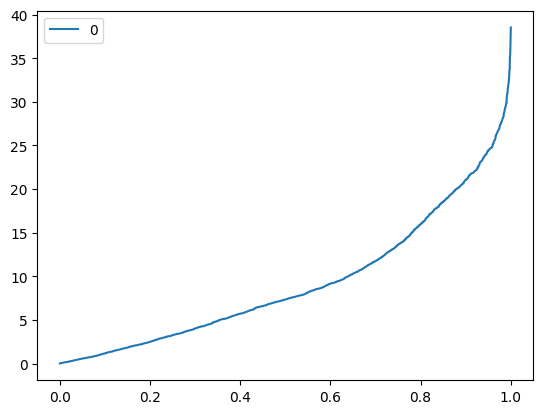

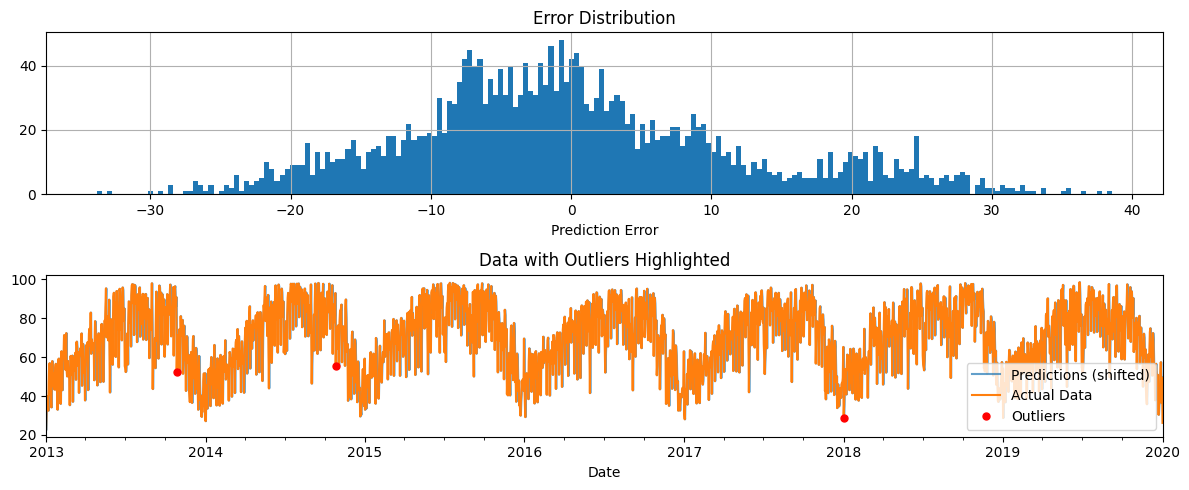

array([ 299,  663, 1826])

In [45]:
def outlier_detector(df, n_sigma=3.):

    # forecaster: persistent
    preds = df.shift(1)

    # find err std, candidate outliers have error > n_sigma*sigma
    err = preds - df
    sigma = err.std()
    candidates = np.argwhere((err.abs() > sigma*n_sigma).values).ravel()

    pd.DataFrame(err.abs().sort_values().values[:-1], index=np.linspace(0, 1, len(err)-1)).plot()

    # if candidate outliers are consecutive, keep only the first
    is_outlier = []
    for i, c in enumerate(candidates):
        if i == 0 or candidates[i-1] != c-1:
            is_outlier.append(c)
    is_outlier = np.array(is_outlier)

    # do nice plots
    fig, ax = plt.subplots(2, 1, figsize=(12, 5))
    err.hist(bins=200, ax=ax[0])
    ax[0].set_title('Error Distribution')
    ax[0].set_xlabel('Prediction Error')
    
    preds.plot(ax=ax[1], label='Predictions (shifted)', alpha=0.7)
    df.plot(ax=ax[1], label='Actual Data')
    if len(is_outlier) > 0:
        ax[1].plot(df.index[is_outlier], df.iloc[is_outlier].values, 'r.', markersize=10, label='Outliers')
    ax[1].set_title('Data with Outliers Highlighted')
    ax[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    return is_outlier

outlier_detector(df_boston['Revenue'])
outlier_detector(df_boston['Demand'])
outlier_detector(df_boston['Occupancy'])

Outliers in the Revenue, Demand and Occupancy time series are not many and do not seem to affect the overall trend and seasonality of the data. Therefore, we decide to keep them as they are, as they may represent real-world events that could be important for forecasting.

---

# Correlation Analysis

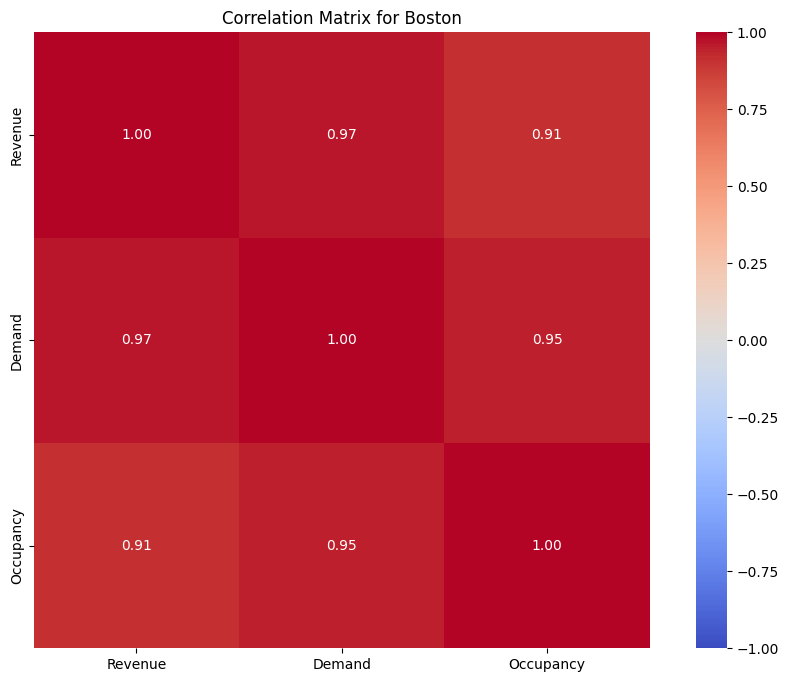

In [49]:
# Correlation Analysis
import seaborn as sns
import matplotlib.pyplot as plt

def plot_correlation_matrix(df, title='Correlation Matrix'):
    plt.figure(figsize=(12, 8))
    sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, vmin=-1, vmax=1)
    plt.title(title)
    plt.show()

plot_correlation_matrix(df_boston[['Revenue', 'Demand', 'Occupancy']], title=f'Correlation Matrix for {CITY}')

Occupancy and Demand show a strong positive correlation with Revenue, indicating that higher occupancy rates and demand levels are associated with increased revenue. This suggests that these variables are important predictors for forecasting revenue in the hotel industry but using them directly may introduce multicollinearity issues in some models.
But in our case we will use them as exogenous variables in our models so it should be fine.

Given the strong correlations observed, we could use both either only Demand or only Occupancy as exogenous variables in our forecasting models to predict Revenue. However, using both variables may provide complementary information that could enhance the model's predictive performance.

Models that can incorporate multiple exogenous variables, such as SARIMAX or LSTM, would be suitable choices for this forecasting task.

---

# Adjusting for inflation
In this section we try to adjust the Revenue time series for inflation to ensure that our forecasts reflect real purchasing power over time but also to **mitigate the long-term effects of inflation**. The impact might not be very significant given the relatively short time span of the data (7 years), but it is still a good practice to account for inflation in financial time series analysis.

In [ ]:
import pandas as pd
import numpy as np

def adjust_for_inflation(df, revenue_column='Revenue', cpi_series=None, base_year=2013):
    if cpi_series is None:
        raise ValueError("CPI series must be provided. You can obtain CPI data from sources like FRED or BLS.")
    
    # Create a copy of the DataFrame
    df_adjusted = df.copy()
    
    # Get CPI for base year
    base_cpi_value = cpi_series.get(base_year)
    if base_cpi_value is None:
        raise ValueError(f"CPI data for base year {base_year} not found")
    
    # Map yearly CPI values to each date in the DataFrame
    cpi_mapped = df_adjusted.index.year.map(cpi_series)
    
    # Calculate inflation-adjusted revenue
    df_adjusted[f'{revenue_column}_real'] = df_adjusted[revenue_column] * (base_cpi_value / cpi_mapped)
    
    return df_adjusted

In [41]:
import pandas as pd
import numpy as np

# CPI data from the provided table (as a dictionary with year as key)
cpi_annual = {
    2013: 232.96,
    2014: 236.74,
    2015: 237.02,
    2016: 240.01,
    2017: 245.12,
    2018: 251.11,
    2019: 255.66,
    2020: 258.81
}

# Now apply the inflation adjustment function with the annual CPI
df_boston_adjusted = adjust_for_inflation(df_boston, cpi_series=cpi_annual)

# Display the first few rows of the adjusted DataFrame
print(df_boston_adjusted.head())

           Location        Revenue       Demand  Occupancy    weekday  \
Date                                                                    
2013-01-01   Boston  166542.843005  1896.791481  22.856617    Tuesday   
2013-01-02   Boston  245252.313124  2744.958462  33.077154  Wednesday   
2013-01-03   Boston  289687.425946  3172.063926  38.223838   Thursday   
2013-01-04   Boston  297390.047491  3308.052694  39.862523     Friday   
2013-01-05   Boston  291848.455941  3235.525351  38.988557   Saturday   

              Revenue_Adj   Revenue_real  
Date                                      
2013-01-01  181856.658978  166542.843005  
2013-01-02  267803.560132  245252.313124  
2013-01-03  316324.535356  289687.425946  
2013-01-04  324735.422274  297390.047491  
2013-01-05  318684.274675  291848.455941  


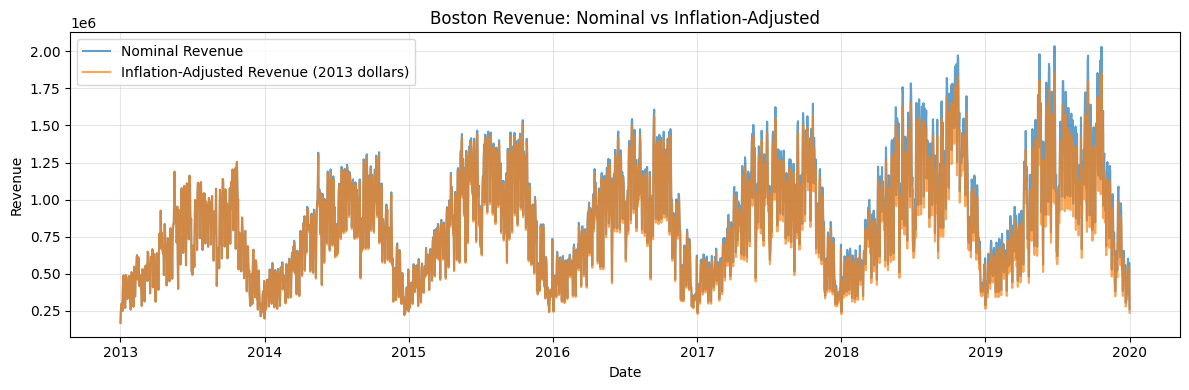


Inflation Impact Summary:
Nominal Revenue Range: $166542.84 - $2035876.60
Inflation-Adjusted Revenue Range: $166542.84 - $1855111.53
Mean Nominal: $867815.46
Mean Inflation-Adjusted: $830661.73


In [42]:

# Plot comparison between nominal and inflation-adjusted revenue
plt.figure(figsize=(12, 4))
plt.plot(df_boston_adjusted['Revenue'], label='Nominal Revenue', alpha=0.7)
plt.plot(df_boston_adjusted['Revenue_real'], label='Inflation-Adjusted Revenue (2013 dollars)', alpha=0.7)
plt.title(f'{CITY} Revenue: Nominal vs Inflation-Adjusted')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Show the difference (inflation impact)
print(f"\nInflation Impact Summary:")
print(f"Nominal Revenue Range: ${df_boston_adjusted['Revenue'].min():.2f} - ${df_boston_adjusted['Revenue'].max():.2f}")
print(f"Inflation-Adjusted Revenue Range: ${df_boston_adjusted['Revenue_real'].min():.2f} - ${df_boston_adjusted['Revenue_real'].max():.2f}")
print(f"Mean Nominal: ${df_boston_adjusted['Revenue'].mean():.2f}")
print(f"Mean Inflation-Adjusted: ${df_boston_adjusted['Revenue_real'].mean():.2f}")


In [43]:

# Compare forecastability indicators: Nominal vs Inflation-Adjusted
print("=" * 80)
print("FORECASTABILITY COMPARISON: Nominal vs Inflation-Adjusted Revenue")
print("=" * 80)

# Compute forecastability indicators for both series
series_nominal = df_boston_adjusted['Revenue'].values
series_adjusted = df_boston_adjusted['Revenue_real'].values

# Nominal series indicators
features_nominal = {}
features_nominal['variance_ratio'] = variance_ratio(series_nominal)
features_nominal['dfa_alpha'] = dfa_alpha_safe(series_nominal)
features_nominal.update(spectral_measures(series_nominal))
features_nominal.update(ordinal_entropy(series_nominal))
features_nominal.update(acf_measures(series_nominal))

# Inflation-adjusted series indicators
features_adjusted = {}
features_adjusted['variance_ratio'] = variance_ratio(series_adjusted)
features_adjusted['dfa_alpha'] = dfa_alpha_safe(series_adjusted)
features_adjusted.update(spectral_measures(series_adjusted))
features_adjusted.update(ordinal_entropy(series_adjusted))
features_adjusted.update(acf_measures(series_adjusted))

# Create comparison table
comparison_data = []
for key in features_nominal.keys():
    nominal_val = features_nominal[key]
    adjusted_val = features_adjusted[key]
    diff = adjusted_val - nominal_val if (not np.isnan(nominal_val) and not np.isnan(adjusted_val)) else np.nan
    comparison_data.append({
        'Indicator': key,
        'Nominal': f"{nominal_val:.4f}" if not np.isnan(nominal_val) else "NaN",
        'Adjusted': f"{adjusted_val:.4f}" if not np.isnan(adjusted_val) else "NaN",
        'Difference': f"{diff:.4f}" if not np.isnan(diff) else "NaN"
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n")
print(comparison_df.to_string(index=False))

# Interpretation
print("\n" + "=" * 80)
print("INTERPRETATION")
print("=" * 80)

print("\nKey Forecastability Indicators Analysis:")
print("-" * 80)

vr_nominal = features_nominal['variance_ratio']
vr_adjusted = features_adjusted['variance_ratio']
print(f"\n1. VARIANCE RATIO (lower is better for forecasting - indicates trend presence):")
print(f"   Nominal:  {vr_nominal:.4f}")
print(f"   Adjusted: {vr_adjusted:.4f}")
if vr_adjusted < vr_nominal:
    print(f"   ✓ Adjusted is BETTER (less trend, more predictable)")
else:
    print(f"   ✗ Nominal is BETTER")

se_nominal = features_nominal['spectral_entropy']
se_adjusted = features_adjusted['spectral_entropy']
print(f"\n2. SPECTRAL ENTROPY (lower is better - indicates more predictability):")
print(f"   Nominal:  {se_nominal:.4f}")
print(f"   Adjusted: {se_adjusted:.4f}")
if se_adjusted < se_nominal:
    print(f"   ✓ Adjusted is BETTER (less entropy, more predictable)")
else:
    print(f"   ✗ Nominal is BETTER")

pe_nominal = features_nominal['ordpy_perm_entropy']
pe_adjusted = features_adjusted['ordpy_perm_entropy']
print(f"\n3. PERMUTATION ENTROPY (lower is better - indicates simpler dynamics):")
print(f"   Nominal:  {pe_nominal:.4f}")
print(f"   Adjusted: {pe_adjusted:.4f}")
if pe_adjusted < pe_nominal:
    print(f"   ✓ Adjusted is BETTER (simpler patterns)")
else:
    print(f"   ✗ Nominal is BETTER")

acf1_nominal = features_nominal['acf1']
acf1_adjusted = features_adjusted['acf1']
print(f"\n4. ACF AT LAG 1 (higher is better - indicates stronger autocorrelation):")
print(f"   Nominal:  {acf1_nominal:.4f}")
print(f"   Adjusted: {acf1_adjusted:.4f}")
if abs(acf1_adjusted) > abs(acf1_nominal):
    print(f"   ✓ Adjusted is BETTER (stronger autocorrelation)")
else:
    print(f"   ✗ Nominal is BETTER")

print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
better_count = 0
if vr_adjusted < vr_nominal:
    better_count += 1
if se_adjusted < se_nominal:
    better_count += 1
if pe_adjusted < pe_nominal:
    better_count += 1
if abs(acf1_adjusted) > abs(acf1_nominal):
    better_count += 1

if better_count >= 3:
    print("\n✓ INFLATION-ADJUSTED series appears MORE FORECASTABLE")
    print("  Reason: Cleaner signal with reduced noise from inflation effects")
elif better_count <= 1:
    print("\n✗ NOMINAL series appears MORE FORECASTABLE")
    print("  Reason: Stronger underlying patterns retained in nominal values")
else:
    print("\n≈ BOTH series are comparably forecastable with different characteristics")
    print("  Recommendation: Test both in your forecasting models")


FORECASTABILITY COMPARISON: Nominal vs Inflation-Adjusted Revenue


               Indicator Nominal Adjusted Difference
          variance_ratio  0.3202   0.3326     0.0125
               dfa_alpha  1.0979   1.1008     0.0029
        spectral_entropy  0.5821   0.5812    -0.0008
spectral_forecastability  0.4179   0.4188     0.0008
       periodicity_index  0.5308   0.5385     0.0077
      ordpy_perm_entropy  0.8706   0.8706     0.0000
   ordpy_stat_complexity  0.2013   0.2013     0.0000
                    acf1  0.8387   0.8324    -0.0063
            acf_mean_abs  0.5666   0.5500    -0.0166

INTERPRETATION

Key Forecastability Indicators Analysis:
--------------------------------------------------------------------------------

1. VARIANCE RATIO (lower is better for forecasting - indicates trend presence):
   Nominal:  0.3202
   Adjusted: 0.3326
   ✗ Nominal is BETTER

2. SPECTRAL ENTROPY (lower is better - indicates more predictability):
   Nominal:  0.5821
   Adjusted: 0.5812
   ✓ Ad

Still the Nominal series apperars to be the most suitable for our forecasting purposes, as the inflation adjustment does not significantly alter the underlying patterns in the data.So we'll keep the Nominal Revenue series for our forecasting models.

---